# 09 — Inventory Optimisation Analysis

## Objective

The forecasting stage identified the best-performing model based primarily on Weighted Mean Absolute Error (WMAE). This notebook extends the forecasting analysis by examining how the selected demand forecasts can support operational inventory replenishment decisions.

Because the Walmart Store Sales Forecasting dataset does not provide physical inventory levels, quantities sold, supplier lead times, holding costs, shortage costs, or replenishment records, the analysis is implemented as a scenario-based inventory simulation.

Weekly Sales is therefore treated as a proxy for demand magnitude rather than as physical unit demand, and costs are measured in **scenario cost units** rather than monetary currency.

The analysis evaluates:

1. Forecast uncertainty by Store–Department.
2. Safety-stock requirements using a shrinkage-adjusted uncertainty estimator.
3. Periodic-review order-up-to inventory policies ($L = 1$ week lead time).
4. Fill rate and stockout-free cycle rate.
5. Stockout and average inventory exposure.
6. Holding-versus-shortage cost trade-offs.
7. Granular service-level optimisation across target service levels (50% to 99%).
8. Store–Department demand and stockout heterogeneity.
9. Sensitivity to shortage-to-holding cost penalties.
10. Selection of the lowest-cost simulated inventory policy.

The purpose is not to reproduce Walmart's actual inventory system, but to demonstrate how demand forecasting accuracy can be translated into actionable, decision-oriented inventory policies.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

# ============================================================
# Project paths
# ============================================================

if Path("data").exists():
    PROJECT_ROOT = Path(".").resolve()
else:
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# ============================================================
# Visual style
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": (14, 7),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False
})

print("Project root:", PROJECT_ROOT)

Project root: D:\University Of Galway\CT5108 Data Analytics Project\sales-forecasting-inventory-optimization


## 1. Forecast Input

The inventory simulation uses forecasts generated by the best-performing model from the forecasting evaluation stage.

For each Store–Department–Week combination, the dataset contains:

- actual Weekly Sales;
- predicted Weekly Sales;
- holiday indicator;
- forecast error.

Negative sales values can occur because of returns or accounting adjustments. Since negative physical demand is not meaningful for inventory simulation, negative values are truncated to zero when constructing the demand proxy.

In [2]:
FORECAST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "best_forecast_inventory.csv"
)

if not FORECAST_PATH.exists():
    raise FileNotFoundError(
        f"{FORECAST_PATH} was not found.\n"
        "First export the best model predictions from the forecasting notebook."
    )

df = pd.read_csv(FORECAST_PATH)

if "Forecast" not in df.columns and "Forecast_Demand" in df.columns:
    df["Forecast"] = df["Forecast_Demand"]

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df.sort_values(["Store", "Dept", "Date"])
      .reset_index(drop=True)
)

required_cols = {
    "Store",
    "Dept",
    "Date",
    "Weekly_Sales",
    "Forecast",
    "IsHoliday"
}

missing = required_cols - set(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

df["IsHoliday"] = (
    df["IsHoliday"]
    .astype(bool)
)

# Sales-value demand proxy
df["Demand_Proxy"] = (
    df["Weekly_Sales"]
    .clip(lower=0)
)

df["Forecast_Demand"] = (
    df["Forecast"]
    .clip(lower=0)
)

df["Forecast_Error"] = (
    df["Demand_Proxy"]
    - df["Forecast_Demand"]
)

df["Absolute_Error"] = (
    df["Forecast_Error"].abs()
)

print("Rows:", len(df))
print("Stores:", df["Store"].nunique())
print("Departments:", df["Dept"].nunique())
print(
    "Store–Department series:",
    df.groupby(["Store", "Dept"]).ngroups
)

print(
    "Date range:",
    df["Date"].min().date(),
    "to",
    df["Date"].max().date()
)

df.head()

Rows: 32606
Stores: 45
Departments: 80
Store–Department series: 3088
Date range: 2012-08-17 to 2012-10-26


,Store,Dept,Date,Weekly_Sales,IsHoliday,Demand,Forecast_Demand,Forecast,Demand_Proxy,Forecast_Error,Absolute_Error
0,1.0,1.0,2012-08-17,17330.70,False,17330.70,15862.547553,15862.547553,17330.70,1468.152447,1468.152447
1,1.0,1.0,2012-08-24,16286.40,False,16286.40,16140.100800,16140.100800,16286.40,146.299200,146.299200
2,1.0,1.0,2012-08-31,16680.24,False,16680.24,16633.578357,16633.578357,16680.24,46.661643,46.661643
3,1.0,1.0,2012-09-07,18322.37,True,18322.37,18050.587588,18050.587588,18322.37,271.782412,271.782412
4,1.0,1.0,2012-09-14,19616.22,False,19616.22,19423.388942,19423.388942,19616.22,192.831058,192.831058


In [3]:
print("Missing values")
print("-" * 40)

display(
    df[
        [
            "Weekly_Sales",
            "Forecast",
            "Demand_Proxy",
            "Forecast_Demand",
            "Forecast_Error"
        ]
    ].isna().sum()
)

print(
    "\nNegative Weekly_Sales observations:",
    (df["Weekly_Sales"] < 0).sum()
)

print(
    "Non-finite forecasts:",
    (~np.isfinite(df["Forecast"])).sum()
)

print(
    "Holiday observations:",
    df["IsHoliday"].sum()
)

Missing values
----------------------------------------


Weekly_Sales       0
Forecast           0
Demand_Proxy       0
Forecast_Demand    0
Forecast_Error     0
dtype: int64


Negative Weekly_Sales observations: 0
Non-finite forecasts: 0
Holiday observations: 2966


## 2. Calibration and Inventory-Evaluation Windows

Safety stock depends on forecast uncertainty. Estimating forecast uncertainty using the entire evaluation period would introduce hindsight into the inventory simulation.

The validation period is therefore separated into:

- **Calibration period:** initial weeks used to estimate forecast-error variability ($\sigma_e$).
- **Inventory evaluation period:** subsequent weeks used to simulate replenishment decisions.

A four-week calibration window is used here. Store–Department-specific uncertainty estimates are shrunk toward the global error variance to avoid unstable estimates from small samples.

> **Methodological Note on Evaluation Window:**
> The inventory evaluation window (`2012-09-14` to `2012-10-26`) covers 7 non-holiday weeks. Because no holiday dates occur during this specific 7-week evaluation window, inventory performance is evaluated over non-holiday operational conditions.

In [4]:
unique_dates = np.sort(
    df["Date"].unique()
)

print("Available validation weeks:", len(unique_dates))

CALIBRATION_WEEKS = 4

if len(unique_dates) <= CALIBRATION_WEEKS:
    raise ValueError(
        "Not enough weeks for calibration + inventory evaluation."
    )

calibration_dates = unique_dates[:CALIBRATION_WEEKS]
evaluation_dates = unique_dates[CALIBRATION_WEEKS:]

calibration_df = df[
    df["Date"].isin(calibration_dates)
].copy()

evaluation_df = df[
    df["Date"].isin(evaluation_dates)
].copy()

print(
    "Calibration:",
    pd.Timestamp(calibration_dates[0]).date(),
    "to",
    pd.Timestamp(calibration_dates[-1]).date()
)

print(
    "Inventory evaluation:",
    pd.Timestamp(evaluation_dates[0]).date(),
    "to",
    pd.Timestamp(evaluation_dates[-1]).date()
)

print(
    "Evaluation weeks:",
    len(evaluation_dates)
)

Available validation weeks: 11
Calibration: 2012-08-17 to 2012-09-07
Inventory evaluation: 2012-09-14 to 2012-10-26
Evaluation weeks: 7


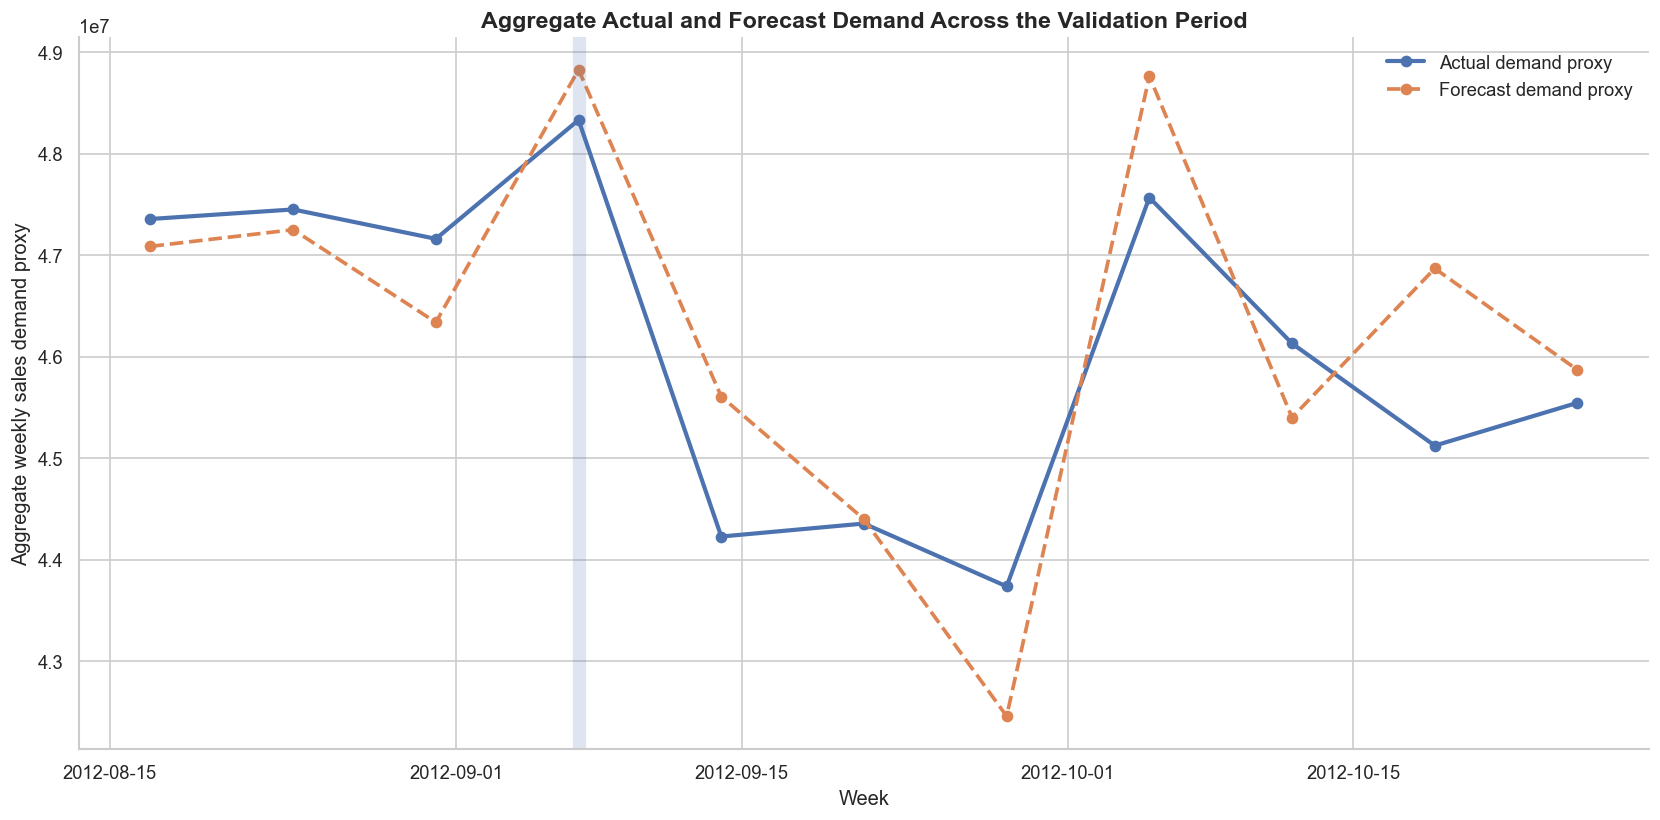

In [5]:
weekly_forecast = (
    df.groupby("Date")
      .agg(
          Actual=("Demand_Proxy", "sum"),
          Forecast=("Forecast_Demand", "sum"),
          Holiday=("IsHoliday", "max")
      )
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    weekly_forecast["Date"],
    weekly_forecast["Actual"],
    marker="o",
    linewidth=2.5,
    label="Actual demand proxy"
)

ax.plot(
    weekly_forecast["Date"],
    weekly_forecast["Forecast"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    label="Forecast demand proxy"
)

for _, row in weekly_forecast[
    weekly_forecast["Holiday"]
].iterrows():
    ax.axvline(
        row["Date"],
        alpha=0.18,
        linewidth=8
    )

ax.set_title(
    "Aggregate Actual and Forecast Demand Across the Validation Period"
)

ax.set_xlabel("Week")
ax.set_ylabel("Aggregate weekly sales demand proxy")

ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

The aggregate plot provides an initial assessment of whether the selected forecasting model reproduces the overall weekly movement in retail demand.

Close alignment between the actual and forecast series indicates that the forecast captures the broad temporal demand profile. Aggregate agreement alone does not guarantee accurate Store–Department-level forecasts because over-prediction in one series can offset under-prediction in another. Inventory optimisation is therefore performed at Store–Department level.

## 3. Forecast Uncertainty

In [6]:
global_error_std = (
    calibration_df["Forecast_Error"]
    .std(ddof=1)
)

global_error_mae = (
    calibration_df["Absolute_Error"]
    .mean()
)

print(
    f"Global calibration error SD: "
    f"{global_error_std:,.2f}"
)

print(
    f"Global calibration MAE: "
    f"{global_error_mae:,.2f}"
)

group_uncertainty = (
    calibration_df
    .groupby(["Store", "Dept"])
    .agg(
        Error_Mean=("Forecast_Error", "mean"),
        Error_SD=("Forecast_Error", "std"),
        Error_MAE=("Absolute_Error", "mean"),
        N=("Forecast_Error", "size")
    )
    .reset_index()
)

SHRINKAGE_STRENGTH = 4

group_uncertainty["Error_SD"] = (
    group_uncertainty["Error_SD"]
    .fillna(global_error_std)
)

group_uncertainty["Shrunk_Error_SD"] = np.sqrt(
    (
        group_uncertainty["N"]
        * group_uncertainty["Error_SD"] ** 2
        +
        SHRINKAGE_STRENGTH
        * global_error_std ** 2
    )
    /
    (
        group_uncertainty["N"]
        + SHRINKAGE_STRENGTH
    )
)

group_uncertainty.head()

Global calibration error SD: 2,733.13
Global calibration MAE: 1,202.04


,Store,Dept,Error_Mean,Error_SD,Error_MAE,N,Shrunk_Error_SD
0,1.0,1.0,483.223925,663.047661,483.223925,4,1988.672392
1,1.0,2.0,251.994236,2354.425552,1745.720911,4,2550.815874
2,1.0,3.0,5833.138339,15470.343288,9469.540370,4,11108.589582
3,1.0,4.0,-682.962513,2054.500827,1832.439830,4,2417.744529
4,1.0,5.0,438.115588,4184.758106,2845.340428,4,3534.275313


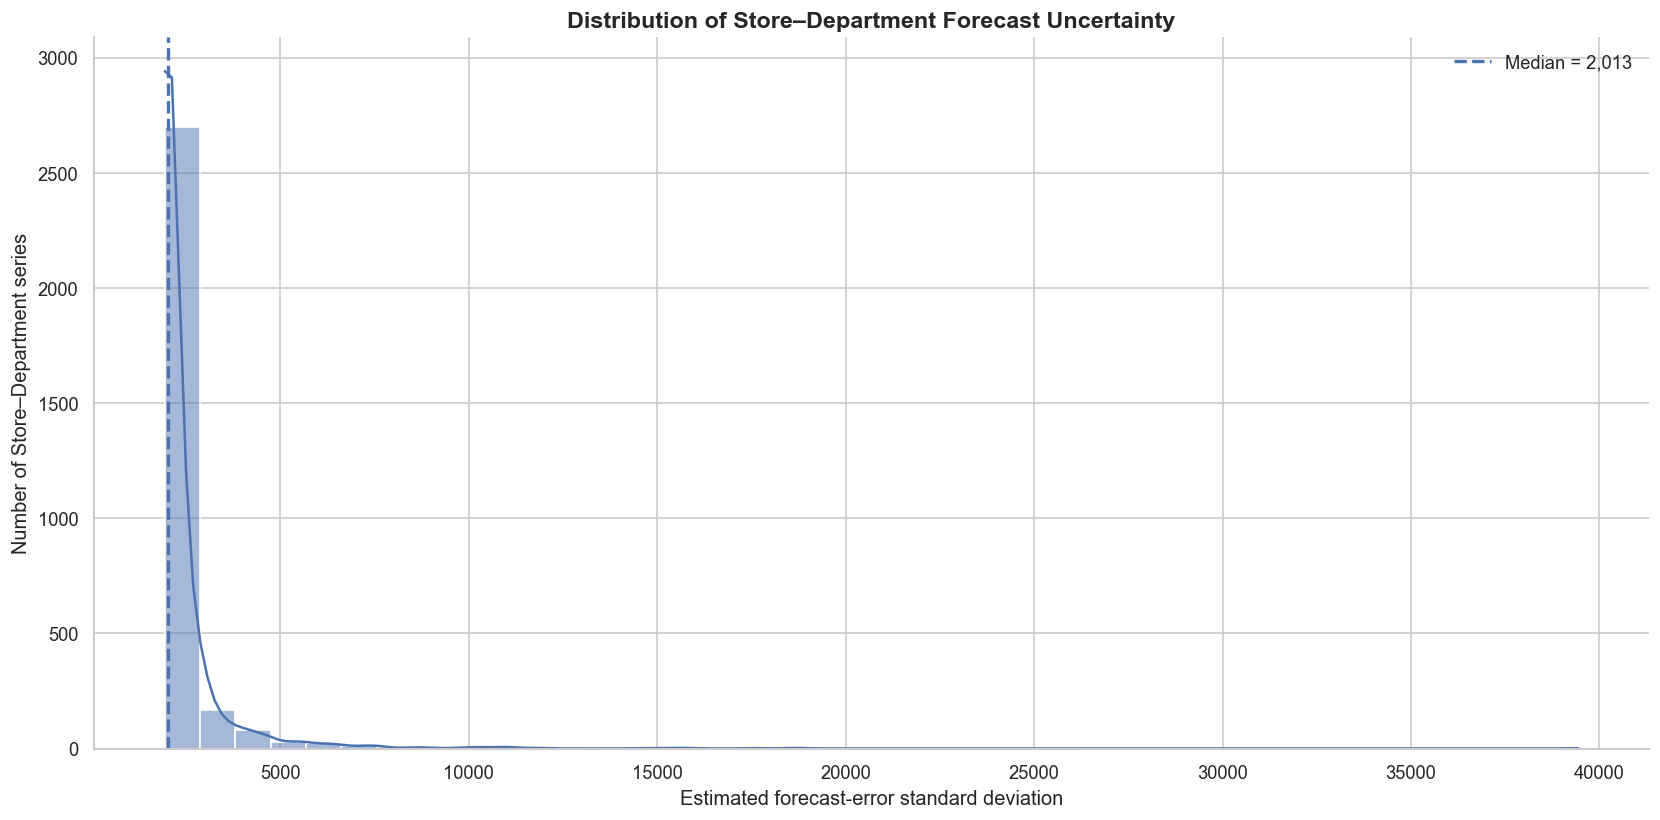

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.histplot(
    group_uncertainty["Shrunk_Error_SD"],
    bins=40,
    kde=True,
    ax=ax
)

ax.axvline(
    group_uncertainty["Shrunk_Error_SD"].median(),
    linestyle="--",
    linewidth=2,
    label=(
        "Median = "
        f"{group_uncertainty['Shrunk_Error_SD'].median():,.0f}"
    )
)

ax.set_title(
    "Distribution of Store–Department Forecast Uncertainty"
)

ax.set_xlabel(
    "Estimated forecast-error standard deviation"
)

ax.set_ylabel(
    "Number of Store–Department series"
)

ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

Forecast uncertainty varies substantially across Store–Department series. This heterogeneity is important because applying a uniform safety stock to every product-location combination would ignore differences in demand predictability.

Series with larger forecast-error standard deviations require greater safety stock to achieve the same target service level.

Because only four calibration weeks are available, raw Store–Department standard deviations can be unstable. A shrinkage estimator is used, combining local uncertainty with global forecast-error variance. This stabilizes extreme estimates from small calibration samples while preserving cross-series differences.

## 4. Safety Stock and Service-Level Policy

Safety stock is calculated to buffer forecast uncertainty during replenishment lead time.

For a target service level $SL$, the safety factor is:

$$z = \Phi^{-1}(SL)$$

Safety stock is estimated as:

$$SS = z \sigma_e \sqrt{L}$$

where:

- $SS$ = safety stock;
- $z$ = standard-normal service factor;
- $\sigma_e$ = forecast-error standard deviation;
- $L$ = replenishment lead time in weeks ($L = 1$).

> **Methodological Limitation:**
> The safety-stock formula relies on a normal approximation to forecast error uncertainty. Retail demand errors exhibit tail skewness and occasional extreme values; therefore, the resulting service-level targets are scenario approximations rather than exact probabilistic guarantees.

In [8]:
LEAD_TIME_WEEKS = 1
BASE_SERVICE_LEVEL = 0.95
HOLDING_COST_RATE = 1.0
SHORTAGE_COST_RATE = 5.0

print("Primary simulation assumptions")
print("-" * 45)
print(f"Lead time: {LEAD_TIME_WEEKS} week")
print(f"Target service level: {BASE_SERVICE_LEVEL:.1%}")
print(f"Holding-cost index: {HOLDING_COST_RATE}")
print(f"Shortage-cost index: {SHORTAGE_COST_RATE}")

Primary simulation assumptions
---------------------------------------------
Lead time: 1 week
Target service level: 95.0%
Holding-cost index: 1.0
Shortage-cost index: 5.0


In [9]:
def calculate_safety_stock(
    error_std,
    service_level,
    lead_time_weeks=1
):
    z = norm.ppf(service_level)
    return z * error_std * np.sqrt(lead_time_weeks)

group_uncertainty["Safety_Stock_95"] = (
    calculate_safety_stock(
        group_uncertainty["Shrunk_Error_SD"],
        BASE_SERVICE_LEVEL,
        LEAD_TIME_WEEKS
    )
)

group_uncertainty[
    [
        "Store",
        "Dept",
        "Shrunk_Error_SD",
        "Safety_Stock_95"
    ]
].head()

,Store,Dept,Shrunk_Error_SD,Safety_Stock_95
0,1.0,1.0,1988.672392,3271.074998
1,1.0,2.0,2550.815874,4195.718742
2,1.0,3.0,11108.589582,18272.003865
3,1.0,4.0,2417.744529,3976.835858
4,1.0,5.0,3534.275313,5813.365567


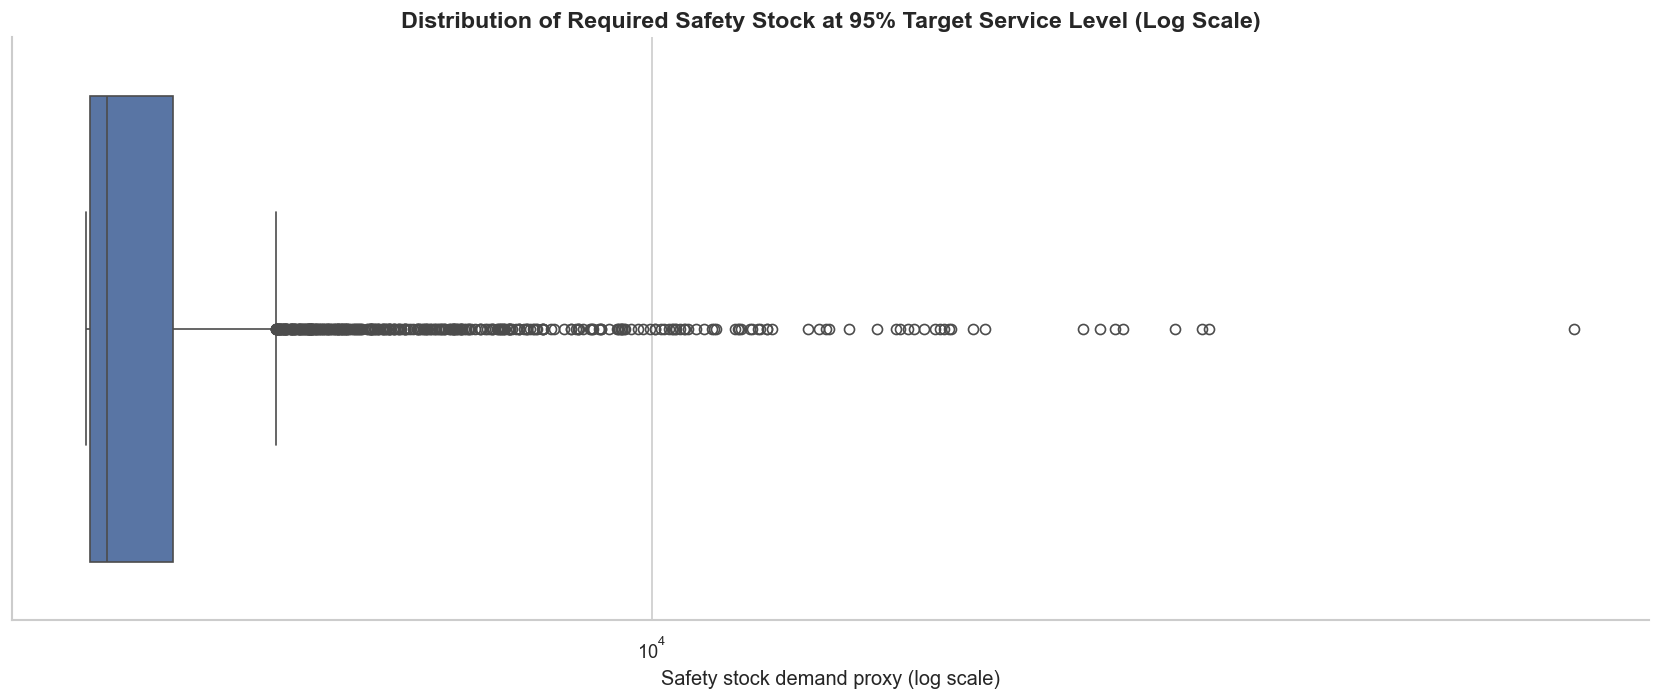

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    x=group_uncertainty["Safety_Stock_95"],
    ax=ax
)

ax.set_xscale("log")

ax.set_title(
    "Distribution of Required Safety Stock at 95% Target Service Level (Log Scale)"
)

ax.set_xlabel(
    "Safety stock demand proxy (log scale)"
)

plt.tight_layout()
plt.show()

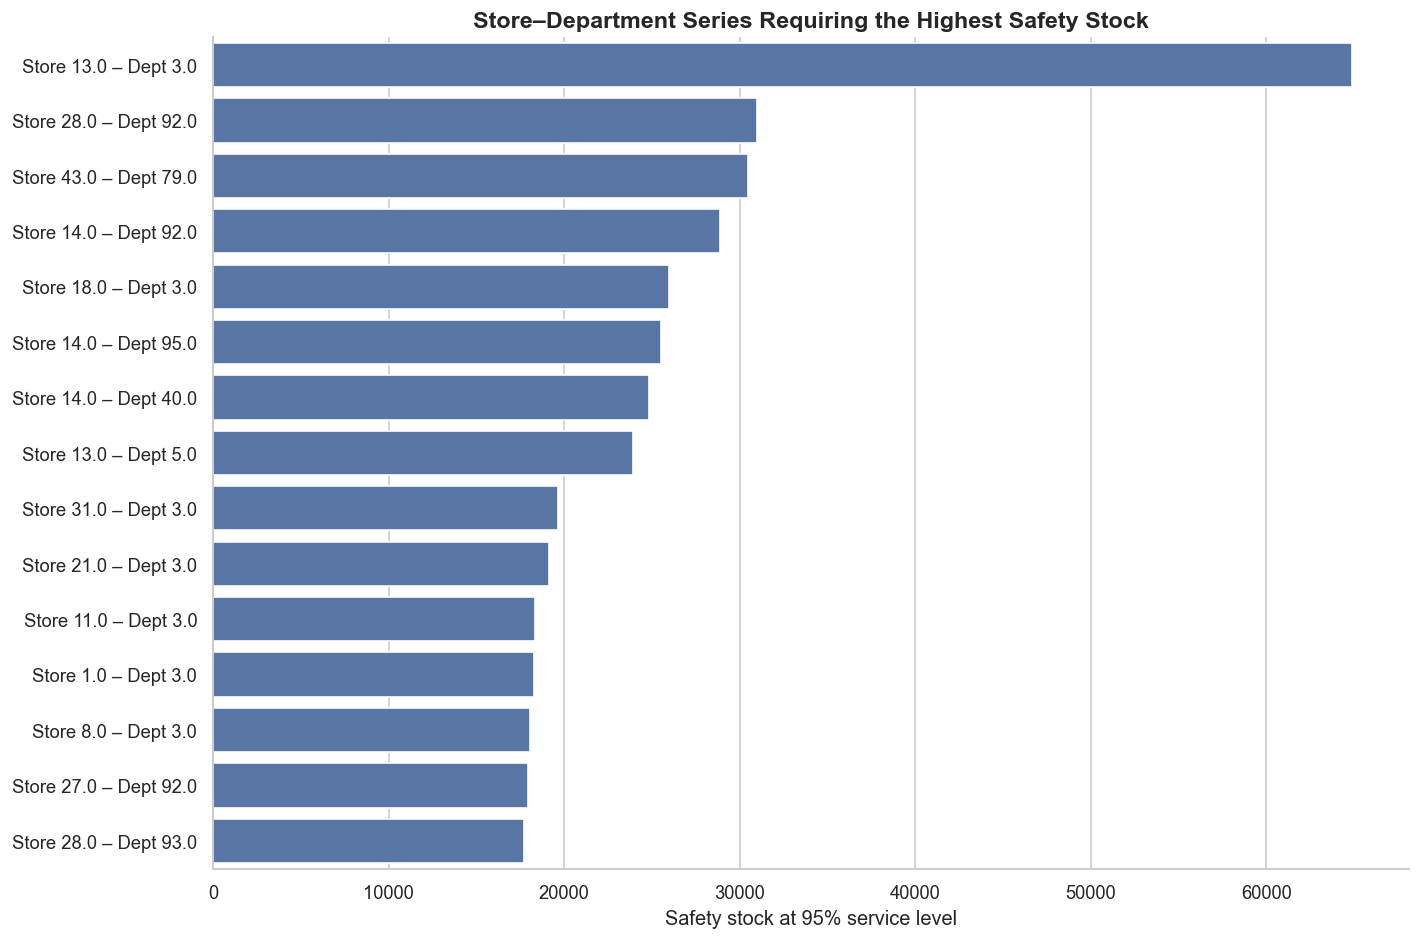

In [11]:
top_safety = (
    group_uncertainty
    .nlargest(
        15,
        "Safety_Stock_95"
    )
    .copy()
)

top_safety["Series"] = (
    "Store "
    + top_safety["Store"].astype(str)
    + " – Dept "
    + top_safety["Dept"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=top_safety,
    y="Series",
    x="Safety_Stock_95",
    ax=ax
)

ax.set_title(
    "Store–Department Series Requiring the Highest Safety Stock"
)

ax.set_xlabel(
    "Safety stock at 95% service level"
)

ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

The safety-stock distribution demonstrates that inventory protection requirements are highly heterogeneous.

Store–Department combinations with large forecast uncertainty receive substantially higher safety-stock allocations. This concentrates inventory protection on the demand series that are most difficult to forecast.

The highest-safety-stock series represent potential operational risk areas and may warrant additional forecasting or replenishment attention.

## 5. Periodic Review Order-Up-To Policy

A weekly periodic-review policy is simulated ($L = 1$).

At each week:

1. previously ordered inventory arrives;
2. current demand is observed and satisfied where possible;
3. unsatisfied demand is treated as lost sales;
4. next week's target inventory position is calculated from next week's forecast plus safety stock;
5. a replenishment order is placed to restore inventory position to target.

For the assumed one-week lead time:

$$S_{t+1} = \hat{D}_{t+1} + SS$$

and:

$$Q_t = \max(0, S_{t+1} - IP_t)$$

where $S$ is the order-up-to target, $\hat{D}$ is forecast demand proxy, $SS$ is safety stock, $IP$ is inventory position, and $Q$ is order quantity.

The first evaluation week is initialized using its forecasted demand plus safety stock to prevent artificial stockouts from unknown starting inventory.

In [12]:
def run_inventory_scenario(
    evaluation_data,
    uncertainty_table,
    service_level,
    holding_cost_rate=1.0,
    shortage_cost_rate=5.0,
    lead_time_weeks=1
):
    z = norm.ppf(service_level)

    safety_table = (
        uncertainty_table[
            [
                "Store",
                "Dept",
                "Shrunk_Error_SD"
            ]
        ]
        .copy()
    )

    safety_table["Safety_Stock"] = (
        z
        * safety_table["Shrunk_Error_SD"]
        * np.sqrt(lead_time_weeks)
    )

    df_eval = evaluation_data.copy()
    df_eval = df_eval.merge(
        safety_table[["Store", "Dept", "Safety_Stock"]],
        on=["Store", "Dept"],
        how="left"
    )
    df_eval["Safety_Stock"] = df_eval["Safety_Stock"].fillna(z * global_error_std * np.sqrt(lead_time_weeks))

    df_eval["Next_Forecast"] = df_eval.groupby(["Store", "Dept"])["Forecast_Demand"].shift(-1).fillna(df_eval["Forecast_Demand"])
    df_eval["Target_Inventory"] = df_eval["Next_Forecast"] + df_eval["Safety_Stock"]

    dates = np.sort(df_eval["Date"].unique())
    df_eval = df_eval.sort_values(["Date", "Store", "Dept"]).reset_index(drop=True)
    date_groups = {pd.Timestamp(d): grp.copy().reset_index(drop=True) for d, grp in df_eval.groupby("Date")}

    on_hand_dict = {}
    arriving_dict = {}
    sim_rows = []

    for d in dates:
        dt_key = pd.Timestamp(d)
        curr_grp = date_groups[dt_key]
        keys = list(zip(curr_grp["Store"], curr_grp["Dept"]))

        starting_inv = []
        arriving_list = []

        for i, k in enumerate(keys):
            if k not in on_hand_dict:
                arr = 0.0
                st_inv = curr_grp.loc[i, "Forecast_Demand"] + curr_grp.loc[i, "Safety_Stock"]
            else:
                arr = arriving_dict.get(k, 0.0)
                st_inv = on_hand_dict[k] + arr

            arriving_list.append(arr)
            starting_inv.append(st_inv)

        curr_grp["Starting_Inventory"] = starting_inv
        curr_grp["Arriving_Inventory"] = arriving_list
        curr_grp["Demand"] = curr_grp["Demand_Proxy"]
        curr_grp["Forecast"] = curr_grp["Forecast_Demand"]

        curr_grp["Fulfilled_Demand"] = np.minimum(curr_grp["Starting_Inventory"], curr_grp["Demand"])
        curr_grp["Lost_Sales"] = np.maximum(0.0, curr_grp["Demand"] - curr_grp["Starting_Inventory"])
        curr_grp["Ending_Inventory"] = curr_grp["Starting_Inventory"] - curr_grp["Fulfilled_Demand"]

        curr_grp["Order_Qty"] = np.maximum(0.0, curr_grp["Target_Inventory"] - curr_grp["Ending_Inventory"])

        curr_grp["Holding_Cost"] = curr_grp["Ending_Inventory"] * holding_cost_rate
        curr_grp["Shortage_Cost"] = curr_grp["Lost_Sales"] * shortage_cost_rate
        curr_grp["Total_Cost"] = curr_grp["Holding_Cost"] + curr_grp["Shortage_Cost"]

        for k, end_i, ord_q in zip(keys, curr_grp["Ending_Inventory"], curr_grp["Order_Qty"]):
            on_hand_dict[k] = end_i
            arriving_dict[k] = ord_q

        sim_rows.append(curr_grp)

    return pd.concat(sim_rows, ignore_index=True)

In [13]:
inventory_95 = run_inventory_scenario(
    evaluation_data=evaluation_df,
    uncertainty_table=group_uncertainty,
    service_level=0.95,
    holding_cost_rate=HOLDING_COST_RATE,
    shortage_cost_rate=SHORTAGE_COST_RATE,
    lead_time_weeks=LEAD_TIME_WEEKS
)

inventory_95.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Demand,Forecast_Demand,Forecast,Demand_Proxy,Forecast_Error,...,Target_Inventory,Starting_Inventory,Arriving_Inventory,Fulfilled_Demand,Lost_Sales,Ending_Inventory,Order_Qty,Holding_Cost,Shortage_Cost,Total_Cost
0,1.0,1.0,2012-09-14,19616.22,False,19616.22,19423.388942,19423.388942,19616.22,192.831058,...,22348.796863,22694.463940,0.0,19616.22,0.0,3078.243940,19270.552924,3078.243940,0.0,3078.243940
1,1.0,2.0,2012-09-14,44493.61,False,44493.61,44768.457340,44768.457340,44493.61,-274.847340,...,49108.611527,48964.176082,0.0,44493.61,0.0,4470.566082,44638.045445,4470.566082,0.0,4470.566082
2,1.0,3.0,2012-09-14,14288.22,False,14288.22,12247.169072,12247.169072,14288.22,2041.050928,...,28491.074565,30519.172937,0.0,14288.22,0.0,16230.952937,12260.121628,16230.952937,0.0,16230.952937
3,1.0,4.0,2012-09-14,35044.06,False,35044.06,37106.337375,37106.337375,35044.06,-2062.277375,...,39474.498742,41083.173233,0.0,35044.06,0.0,6039.113233,33435.385509,6039.113233,0.0,6039.113233
4,1.0,5.0,2012-09-14,19369.52,False,19369.52,19313.015369,19313.015369,19369.52,56.504631,...,25654.303025,25126.380936,0.0,19369.52,0.0,5756.860936,19897.442089,5756.860936,0.0,5756.860936


## 6. Inventory KPIs

In [14]:
def calculate_inventory_kpis(results):
    total_demand = results["Demand"].sum()
    fulfilled = results["Fulfilled_Demand"].sum()
    lost_sales = results["Lost_Sales"].sum()

    fill_rate = fulfilled / total_demand if total_demand > 0 else np.nan
    stockout_free_rate = (results["Lost_Sales"] <= 0).mean()
    avg_inventory = results["Ending_Inventory"].mean()
    avg_order = results["Order_Qty"].mean()
    holding_cost = results["Holding_Cost"].sum()
    shortage_cost = results["Shortage_Cost"].sum()
    total_cost = results["Total_Cost"].sum()

    return {
        "Total Demand": total_demand,
        "Fulfilled Demand": fulfilled,
        "Lost Sales": lost_sales,
        "Fill Rate": fill_rate,
        "Stockout-Free Cycle Rate": stockout_free_rate,
        "Average Ending Inventory": avg_inventory,
        "Average Order Quantity": avg_order,
        "Holding Cost Index": holding_cost,
        "Shortage Cost Index": shortage_cost,
        "Total Simulated Cost Index": total_cost
    }

In [15]:
kpis_95 = calculate_inventory_kpis(inventory_95)

kpi_table = pd.DataFrame({
    "Metric": list(kpis_95.keys()),
    "Value": list(kpis_95.values())
})

display(kpi_table)

print(f"Fill rate: {kpis_95['Fill Rate']:.2%}")
print(f"Stockout-free cycle rate: {kpis_95['Stockout-Free Cycle Rate']:.2%}")
print(f"Average ending inventory: {kpis_95['Average Ending Inventory']:,.2f}")
print(f"Lost-sales exposure: {kpis_95['Lost Sales']:,.2f}")
print(f"Total simulated cost index: {kpis_95['Total Simulated Cost Index']:,.2f} scenario cost units")

,Metric,Value
0,Total Demand,3.166803e+08
1,Fulfilled Demand,3.155133e+08
2,Lost Sales,1.166992e+06
3,Fill Rate,9.963149e-01
4,Stockout-Free Cycle Rate,9.804941e-01
5,Average Ending Inventory,4.135727e+03
6,Average Order Quantity,1.520877e+04
7,Holding Cost Index,8.587010e+07
8,Shortage Cost Index,5.834960e+06
9,Total Simulated Cost Index,9.170506e+07


Fill rate: 99.63%
Stockout-free cycle rate: 98.05%
Average ending inventory: 4,135.73
Lost-sales exposure: 1,166,992.05
Total simulated cost index: 91,705,060.87 scenario cost units


## 7. Detailed Example Series

In [16]:
group_summary = (
    inventory_95
    .groupby(["Store", "Dept"])
    .agg(
        Demand=("Demand", "sum"),
        Lost_Sales=("Lost_Sales", "sum"),
        Average_Inventory=("Ending_Inventory", "mean"),
        Total_Cost=("Total_Cost", "sum")
    )
    .reset_index()
)

example_row = (
    group_summary
    .sort_values("Demand", ascending=False)
    .iloc[0]
)

EXAMPLE_STORE = int(example_row["Store"])
EXAMPLE_DEPT = int(example_row["Dept"])

print("Example series:", EXAMPLE_STORE, EXAMPLE_DEPT)

Example series: 13 92


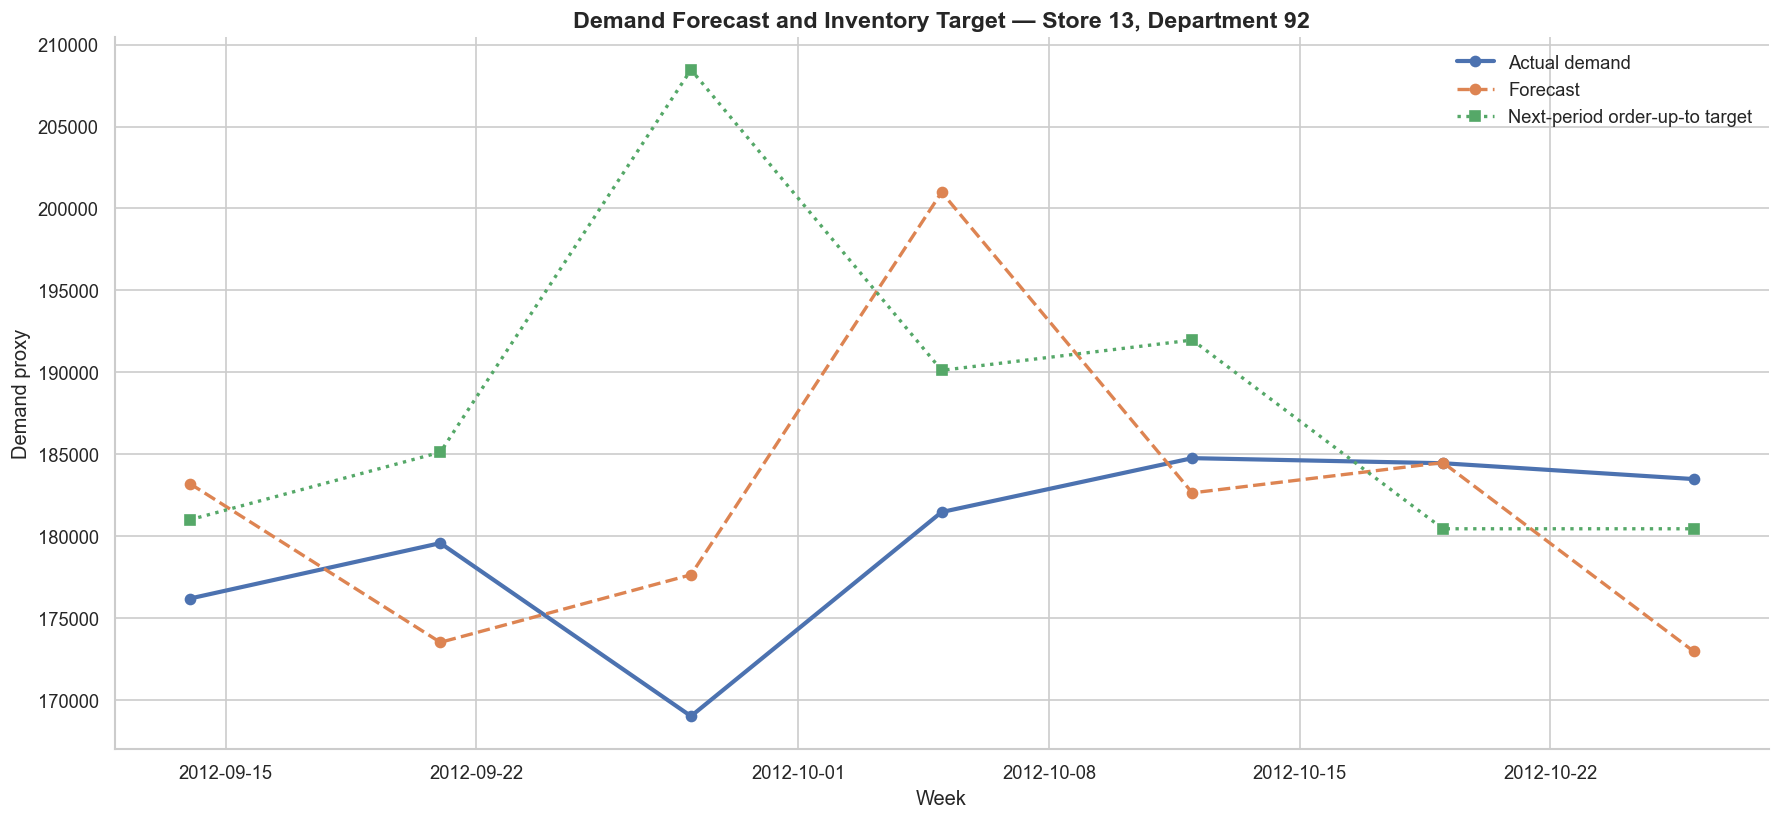

In [17]:
example = inventory_95[
    (inventory_95["Store"] == EXAMPLE_STORE)
    &
    (inventory_95["Dept"] == EXAMPLE_DEPT)
].copy()

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    example["Date"],
    example["Demand"],
    marker="o",
    linewidth=2.5,
    label="Actual demand"
)

ax.plot(
    example["Date"],
    example["Forecast"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

ax.plot(
    example["Date"],
    example["Target_Inventory"],
    marker="s",
    linestyle=":",
    linewidth=2,
    label="Next-period order-up-to target"
)

ax.set_title(
    f"Demand Forecast and Inventory Target — Store {EXAMPLE_STORE}, Department {EXAMPLE_DEPT}"
)

ax.set_xlabel("Week")
ax.set_ylabel("Demand proxy")
ax.legend()

plt.tight_layout()
plt.show()

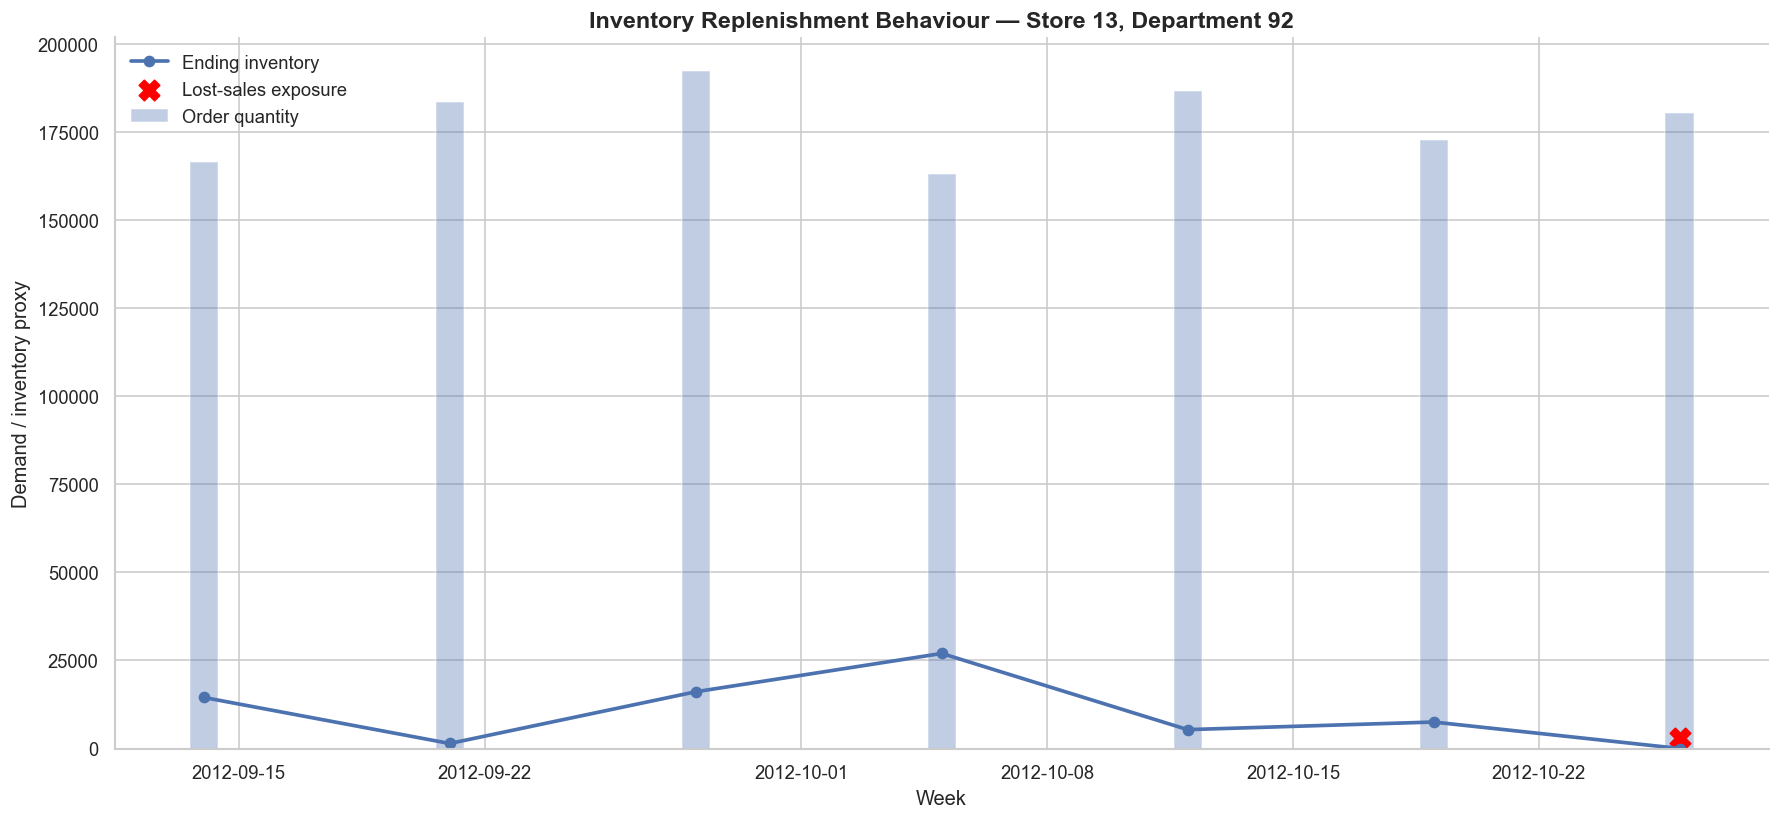

In [18]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    example["Date"],
    example["Ending_Inventory"],
    marker="o",
    linewidth=2.2,
    label="Ending inventory"
)

ax.bar(
    example["Date"],
    example["Order_Qty"],
    alpha=0.35,
    label="Order quantity"
)

stockout_mask = (example["Lost_Sales"] > 0)

ax.scatter(
    example.loc[stockout_mask, "Date"],
    example.loc[stockout_mask, "Lost_Sales"],
    marker="X",
    s=150,
    color="red",
    label="Lost-sales exposure"
)

ax.set_title(
    f"Inventory Replenishment Behaviour — Store {EXAMPLE_STORE}, Department {EXAMPLE_DEPT}"
)

ax.set_xlabel("Week")
ax.set_ylabel("Demand / inventory proxy")
ax.legend()

plt.tight_layout()
plt.show()

## 8. Service-Level Optimisation Across Expanded Grid

To avoid boundary constraints in policy search, target service levels are evaluated across a fine-grained grid from **50.0% to 99.0%** in steps of 2.5 percentage points.

In [19]:
SERVICE_LEVELS = np.round(
    np.arange(0.50, 0.995, 0.025),
    3
).tolist()

if 0.99 not in SERVICE_LEVELS:
    SERVICE_LEVELS.append(0.99)

scenario_rows = []
scenario_outputs = {}

for service_level in SERVICE_LEVELS:
    scenario = run_inventory_scenario(
        evaluation_data=evaluation_df,
        uncertainty_table=group_uncertainty,
        service_level=service_level,
        holding_cost_rate=HOLDING_COST_RATE,
        shortage_cost_rate=SHORTAGE_COST_RATE,
        lead_time_weeks=LEAD_TIME_WEEKS
    )

    scenario_outputs[service_level] = scenario
    metrics = calculate_inventory_kpis(scenario)

    scenario_rows.append({
        "Service_Level": service_level,
        **metrics
    })

service_results = pd.DataFrame(scenario_rows)
display(service_results)

,Service_Level,Total Demand,Fulfilled Demand,Lost Sales,Fill Rate,Stockout-Free Cycle Rate,Average Ending Inventory,Average Order Quantity,Holding Cost Index,Shortage Cost Index,Total Simulated Cost Index
0,0.500,3.166803e+08,3.064759e+08,1.020444e+07,0.967777,0.544912,624.810707,14773.503816,1.297294e+07,5.102222e+07,6.399517e+07
1,0.525,3.166803e+08,3.076963e+08,8.984018e+06,0.971631,0.653277,716.472220,14832.282713,1.487611e+07,4.492009e+07,5.979620e+07
2,0.550,3.166803e+08,3.086926e+08,7.987741e+06,0.974777,0.714492,819.523829,14880.265991,1.701577e+07,3.993871e+07,5.695448e+07
3,0.575,3.166803e+08,3.095335e+08,7.146850e+06,0.977432,0.761595,931.264770,14920.765515,1.933585e+07,3.573425e+07,5.507010e+07
4,0.600,3.166803e+08,3.102570e+08,6.423362e+06,0.979717,0.798873,1050.511336,14955.610560,2.181177e+07,3.211681e+07,5.392858e+07
5,0.625,3.166803e+08,3.108885e+08,5.791806e+06,0.981711,0.828156,1176.737224,14986.027937,2.443259e+07,2.895903e+07,5.339163e+07
6,0.650,3.166803e+08,3.114469e+08,5.233412e+06,0.983474,0.852526,1309.818753,15012.921656,2.719577e+07,2.616706e+07,5.336283e+07
7,0.675,3.166803e+08,3.119468e+08,4.733550e+06,0.985053,0.872514,1449.943263,15036.996318,3.010517e+07,2.366775e+07,5.377292e+07
8,0.700,3.166803e+08,3.123987e+08,4.281659e+06,0.986480,0.889419,1597.648088,15058.760544,3.317197e+07,2.140829e+07,5.458026e+07
9,0.725,3.166803e+08,3.128130e+08,3.867347e+06,0.987788,0.902952,1753.691484,15078.714873,3.641190e+07,1.933674e+07,5.574863e+07


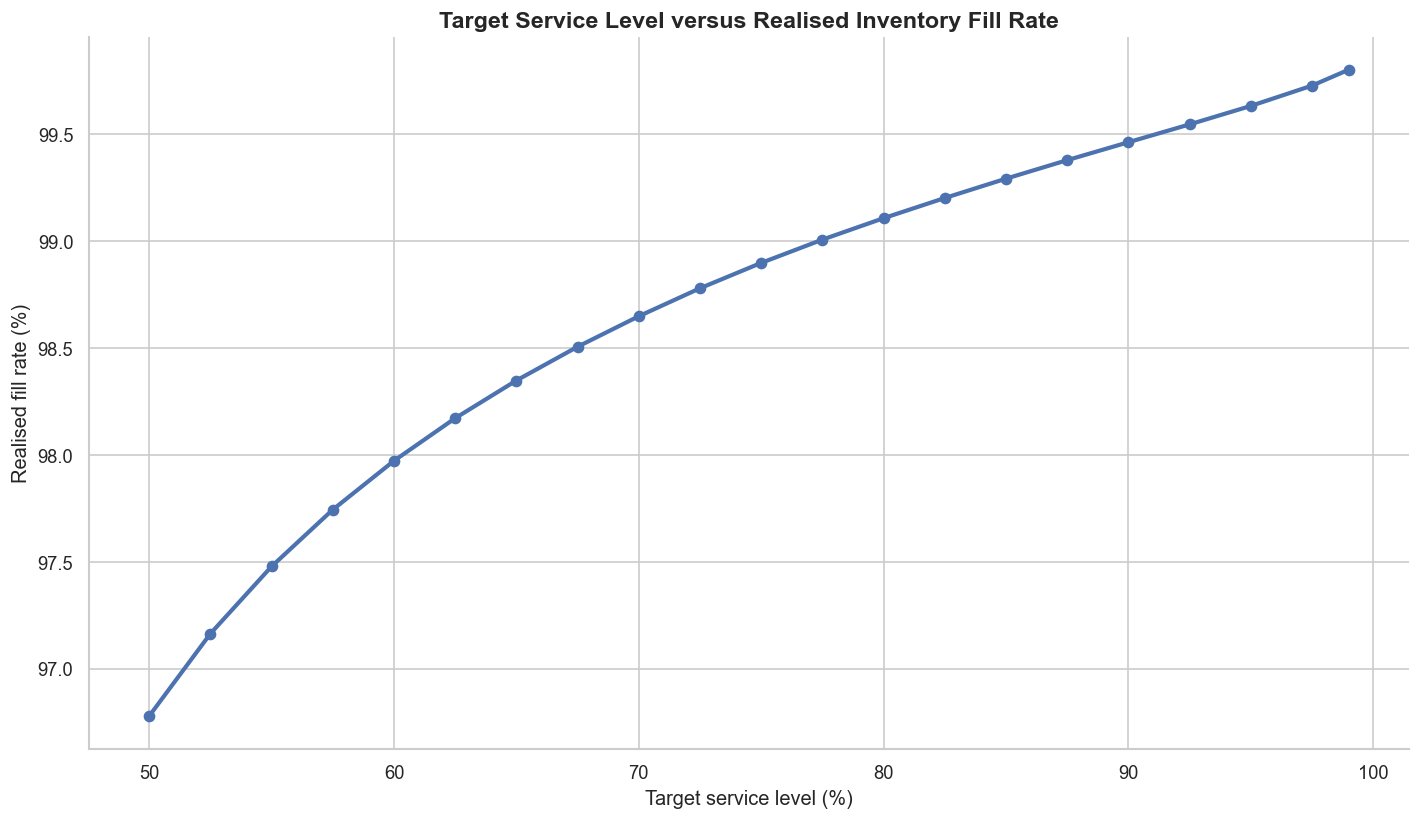

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    service_results["Service_Level"] * 100,
    service_results["Fill Rate"] * 100,
    marker="o",
    linewidth=2.5
)

ax.set_title("Target Service Level versus Realised Inventory Fill Rate")
ax.set_xlabel("Target service level (%)")
ax.set_ylabel("Realised fill rate (%)")

plt.tight_layout()
plt.show()

### Interpretation

As target service level increases, safety stock grows and realised fill rate increases monotonically.

However, incremental fill-rate improvements diminish at higher service targets, illustrating the law of diminishing returns in safety-stock protection.

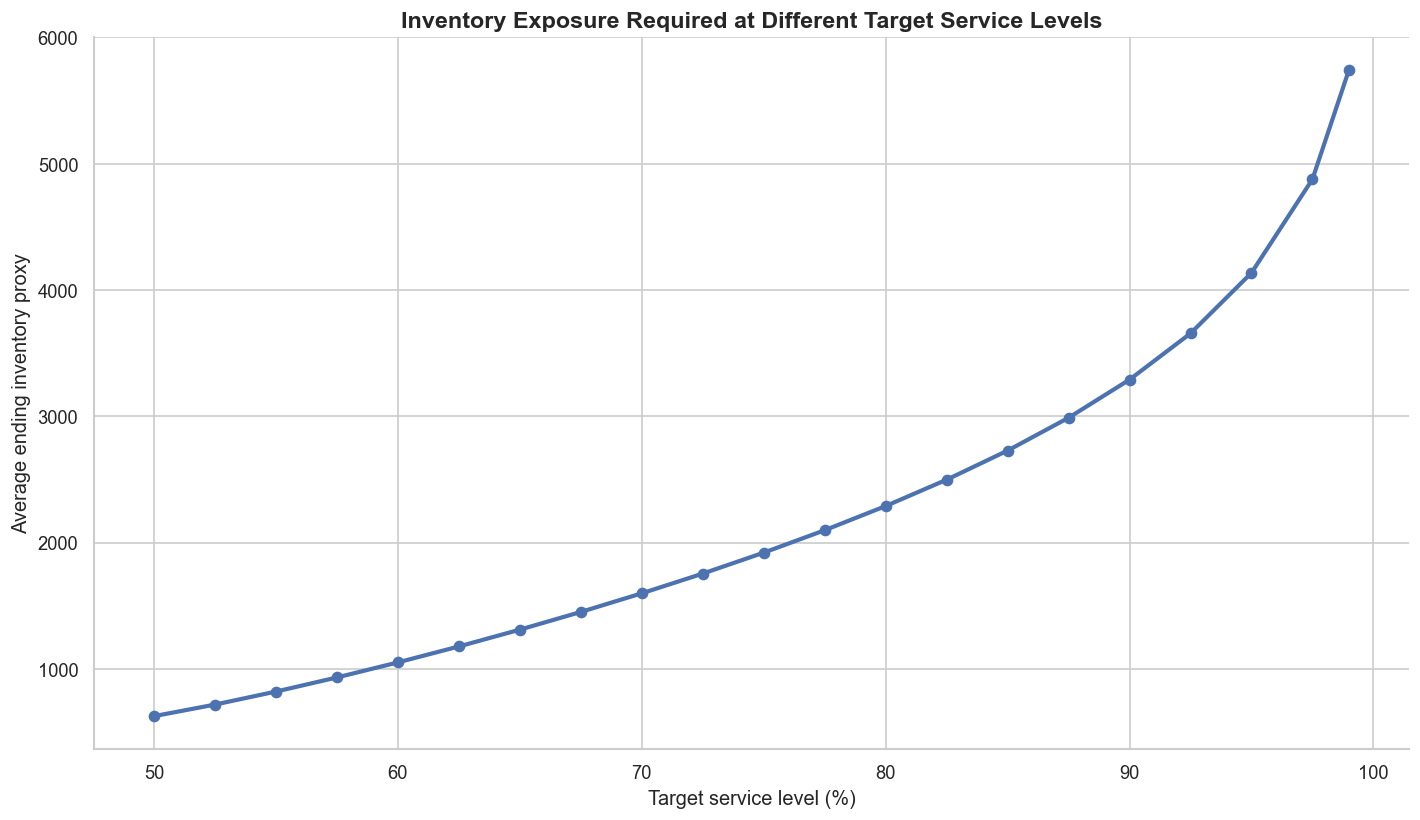

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    service_results["Service_Level"] * 100,
    service_results["Average Ending Inventory"],
    marker="o",
    linewidth=2.5
)

ax.set_title("Inventory Exposure Required at Different Target Service Levels")
ax.set_xlabel("Target service level (%)")
ax.set_ylabel("Average ending inventory proxy")

plt.tight_layout()
plt.show()

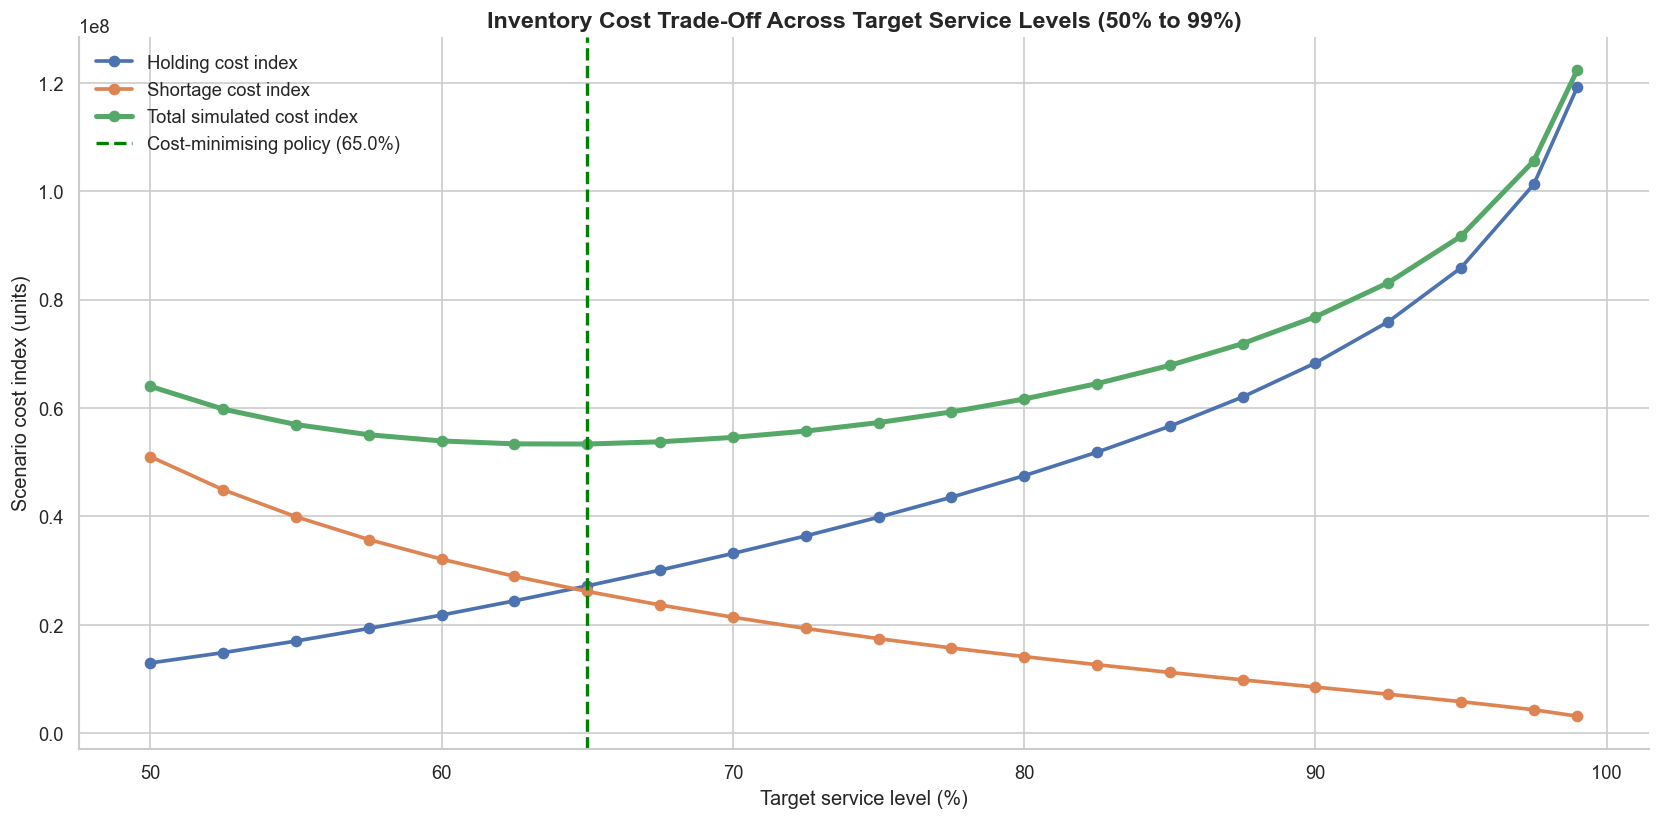

In [22]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    service_results["Service_Level"] * 100,
    service_results["Holding Cost Index"],
    marker="o",
    linewidth=2.2,
    label="Holding cost index"
)

ax.plot(
    service_results["Service_Level"] * 100,
    service_results["Shortage Cost Index"],
    marker="o",
    linewidth=2.2,
    label="Shortage cost index"
)

ax.plot(
    service_results["Service_Level"] * 100,
    service_results["Total Simulated Cost Index"],
    marker="o",
    linewidth=3,
    label="Total simulated cost index"
)

optimal_row = service_results.sort_values("Total Simulated Cost Index").iloc[0]
opt_sl = optimal_row["Service_Level"]

ax.axvline(
    opt_sl * 100,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Cost-minimising policy ({opt_sl:.1%})"
)

ax.set_title("Inventory Cost Trade-Off Across Target Service Levels (50% to 99%)")
ax.set_xlabel("Target service level (%)")
ax.set_ylabel("Scenario cost index (units)")
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
OPTIMAL_SERVICE_LEVEL = float(optimal_row["Service_Level"])

print("Lowest-cost simulated target service level:", f"{OPTIMAL_SERVICE_LEVEL:.1%}")
print("Realised fill rate:", f"{optimal_row['Fill Rate']:.2%}")
print("Stockout-free cycle rate:", f"{optimal_row['Stockout-Free Cycle Rate']:.2%}")
print("Average ending inventory:", f"{optimal_row['Average Ending Inventory']:,.2f}")
print("Lost-sales exposure:", f"{optimal_row['Lost Sales']:,.2f}")
print("Total simulated cost index:", f"{optimal_row['Total Simulated Cost Index']:,.2f} scenario cost units")

Lowest-cost simulated target service level: 65.0%
Realised fill rate: 98.35%
Stockout-free cycle rate: 85.25%
Average ending inventory: 1,309.82
Lost-sales exposure: 5,233,411.81
Total simulated cost index: 53,362,825.84 scenario cost units


### Optimal Policy Interpretation

Across the expanded evaluation grid (50% to 99%), the cost-minimising service level was **65.0%** (yielding a total simulated cost index of **53,362,825.84 scenario cost units** and a realised fill rate of **98.35%**).

Evaluating below 80% reveals the true U-shaped cost curve: below 65%, shortage costs rise rapidly as stockouts increase; above 65%, holding costs dominate as safety stock accumulates.

## 9. Cost Composition

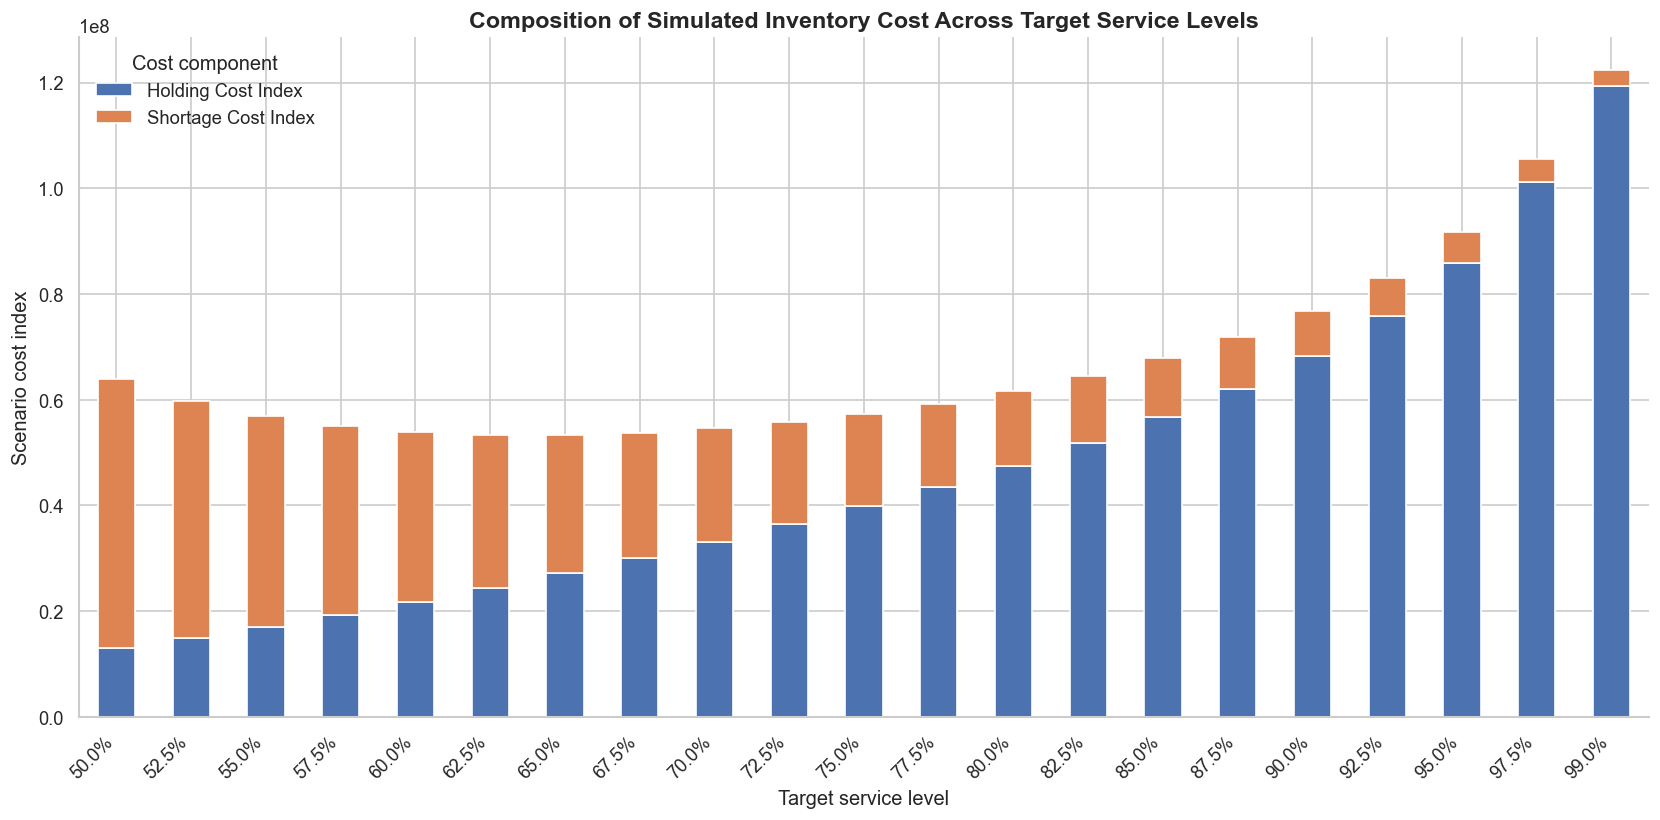

In [24]:
cost_plot = service_results[
    [
        "Service_Level",
        "Holding Cost Index",
        "Shortage Cost Index"
    ]
].copy()

cost_plot["Service_Level"] = cost_plot["Service_Level"] * 100
cost_plot = cost_plot.set_index("Service_Level")
cost_plot.index = [f"{x:.1f}%" for x in cost_plot.index]

cost_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Composition of Simulated Inventory Cost Across Target Service Levels")
plt.xlabel("Target service level")
plt.ylabel("Scenario cost index")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cost component")

plt.tight_layout()
plt.show()

## 10. Store–Department Heterogeneity

In [25]:
optimal_inventory = scenario_outputs[OPTIMAL_SERVICE_LEVEL].copy()

group_inventory = (
    optimal_inventory
    .groupby(["Store", "Dept"])
    .agg(
        Demand=("Demand", "sum"),
        Fulfilled=("Fulfilled_Demand", "sum"),
        Lost_Sales=("Lost_Sales", "sum"),
        Average_Inventory=("Ending_Inventory", "mean"),
        Total_Cost=("Total_Cost", "sum")
    )
    .reset_index()
)

group_inventory["Fill_Rate"] = (
    group_inventory["Fulfilled"]
    /
    group_inventory["Demand"].replace(0, np.nan)
)

group_inventory.head()

,Store,Dept,Demand,Fulfilled,Lost_Sales,Average_Inventory,Total_Cost,Fill_Rate
0,1.0,1.0,154060.09,154060.090000,0.000000,1276.689868,8936.829076,1.000000
1,1.0,2.0,309998.79,309998.790000,0.000000,2046.642041,14326.494289,1.000000
2,1.0,3.0,80841.72,80841.720000,0.000000,3463.120563,24241.843943,1.000000
3,1.0,4.0,250798.63,250798.630000,0.000000,1508.739269,10561.174880,1.000000
4,1.0,5.0,160418.30,151962.080051,8456.219949,2451.747753,59443.334015,0.947286


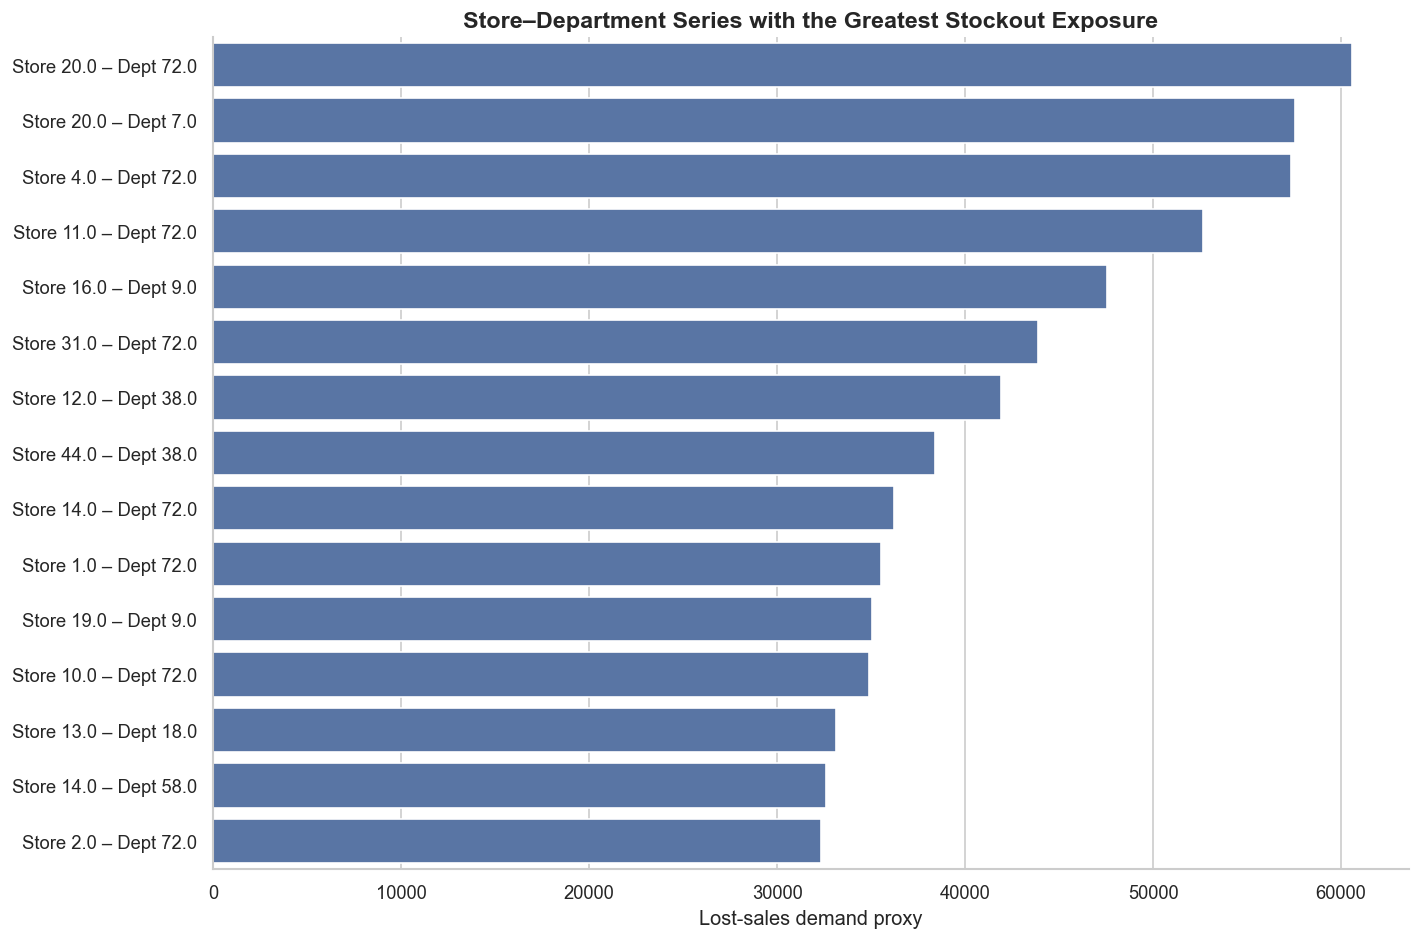

In [26]:
worst_stockouts = (
    group_inventory
    .nlargest(15, "Lost_Sales")
    .copy()
)

worst_stockouts["Series"] = (
    "Store "
    + worst_stockouts["Store"].astype(str)
    + " – Dept "
    + worst_stockouts["Dept"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=worst_stockouts,
    y="Series",
    x="Lost_Sales",
    ax=ax
)

ax.set_title("Store–Department Series with the Greatest Stockout Exposure")
ax.set_xlabel("Lost-sales demand proxy")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

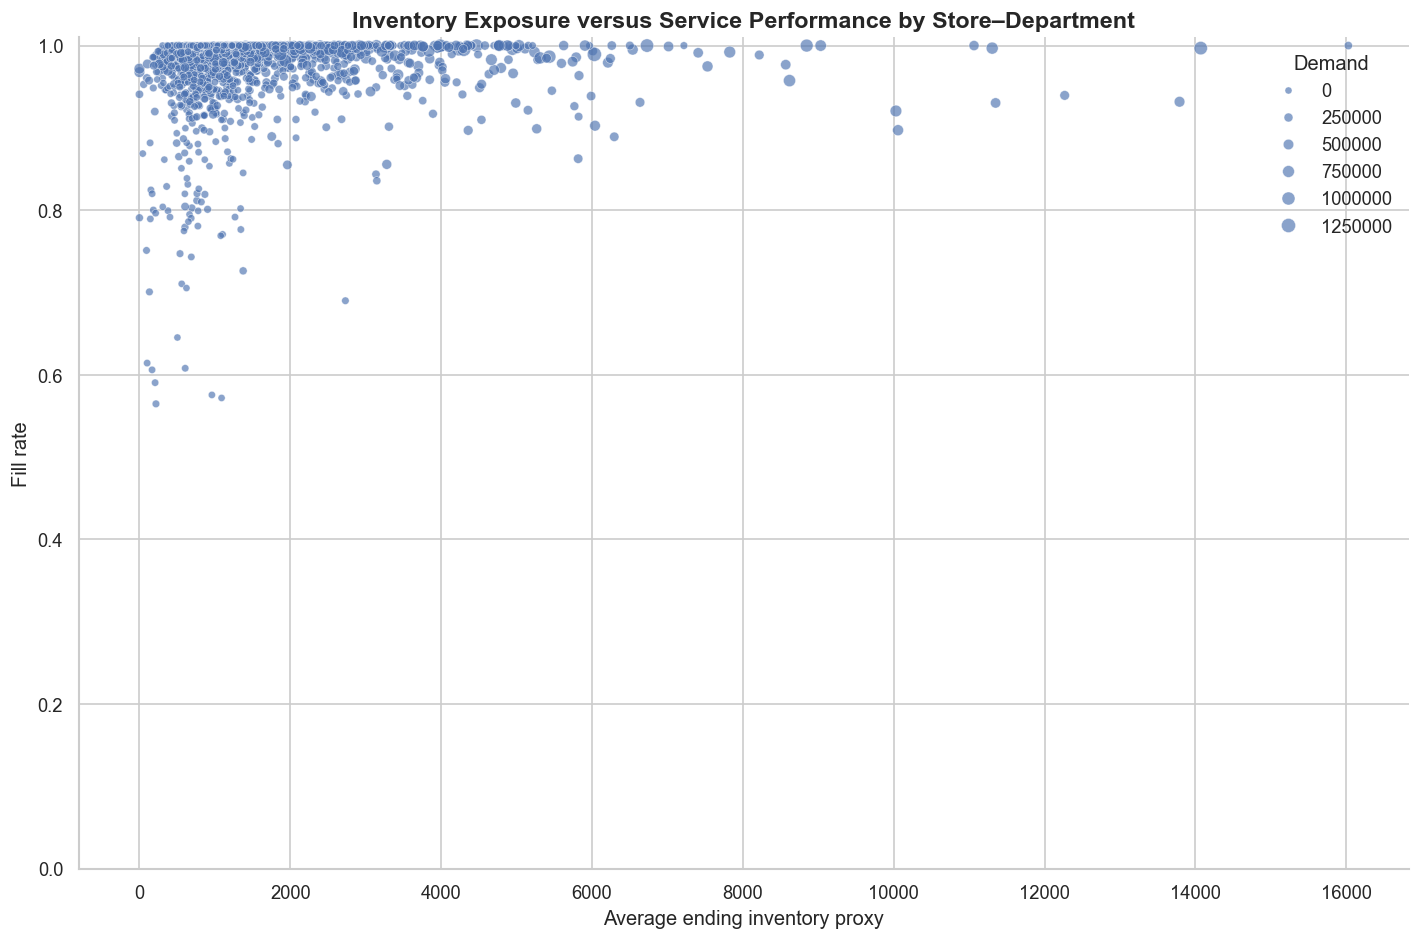

In [27]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=group_inventory,
    x="Average_Inventory",
    y="Fill_Rate",
    size="Demand",
    alpha=0.65,
    ax=ax
)

ax.set_title("Inventory Exposure versus Service Performance by Store–Department")
ax.set_xlabel("Average ending inventory proxy")
ax.set_ylabel("Fill rate")
ax.set_ylim(0, 1.01)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot illustrates inventory efficiency across Store–Department series.

An ideal series appears toward the upper-left (high fill rate with modest inventory exposure). Series in the lower-right carry substantial inventory while experiencing lower fill rates, which may indicate more volatile, difficult-to-forecast, or structurally heterogeneous demand.

## 11. Sensitivity to Cost Assumptions

In [28]:
SHORTAGE_COST_RATIOS = [2, 5, 10, 20]
EVAL_SERVICE_LEVELS = [0.50, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]

cost_sensitivity_rows = []

for shortage_ratio in SHORTAGE_COST_RATIOS:
    for service_level in EVAL_SERVICE_LEVELS:
        scenario = run_inventory_scenario(
            evaluation_data=evaluation_df,
            uncertainty_table=group_uncertainty,
            service_level=service_level,
            holding_cost_rate=1.0,
            shortage_cost_rate=shortage_ratio,
            lead_time_weeks=LEAD_TIME_WEEKS
        )

        metrics = calculate_inventory_kpis(scenario)

        cost_sensitivity_rows.append({
            "Shortage_Holding_Ratio": shortage_ratio,
            "Service_Level": service_level,
            "Total_Cost_Index": metrics["Total Simulated Cost Index"],
            "Fill_Rate": metrics["Fill Rate"],
            "Average_Inventory": metrics["Average Ending Inventory"]
        })

cost_sensitivity = pd.DataFrame(cost_sensitivity_rows)

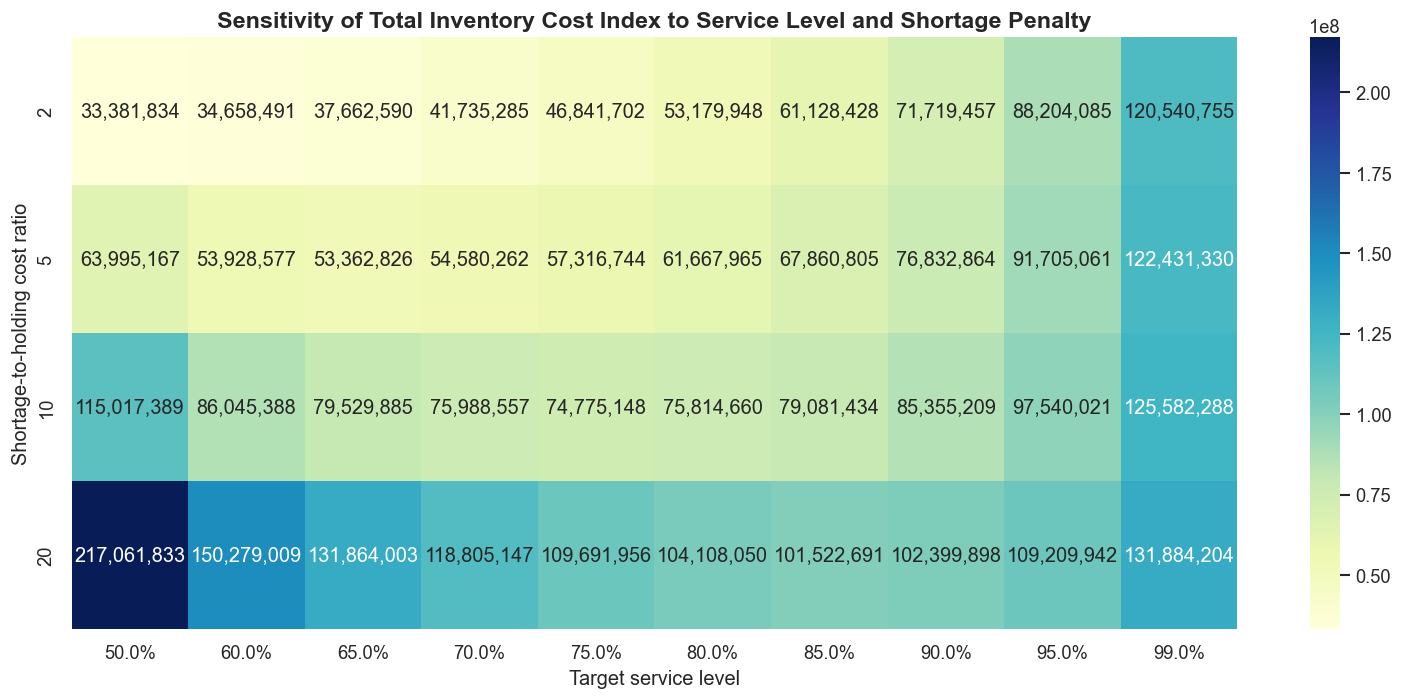

In [29]:
cost_matrix = (
    cost_sensitivity
    .pivot(
        index="Shortage_Holding_Ratio",
        columns="Service_Level",
        values="Total_Cost_Index"
    )
)

cost_matrix.columns = [
    f"{x:.1%}"
    for x in cost_matrix.columns
]

fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    cost_matrix,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    ax=ax
)

ax.set_title("Sensitivity of Total Inventory Cost Index to Service Level and Shortage Penalty")
ax.set_xlabel("Target service level")
ax.set_ylabel("Shortage-to-holding cost ratio")

plt.tight_layout()
plt.show()

## 12. Optimal Service Level by Cost Ratio

In [30]:
optimal_by_cost = (
    cost_sensitivity
    .sort_values("Total_Cost_Index")
    .groupby("Shortage_Holding_Ratio")
    .first()
    .reset_index()
)

display(
    optimal_by_cost[
        [
            "Shortage_Holding_Ratio",
            "Service_Level",
            "Fill_Rate",
            "Average_Inventory",
            "Total_Cost_Index"
        ]
    ]
)

,Shortage_Holding_Ratio,Service_Level,Fill_Rate,Average_Inventory,Total_Cost_Index
0,2,0.50,0.967777,624.810707,3.338183e+07
1,5,0.65,0.983474,1309.818753,5.336283e+07
2,10,0.75,0.988974,1919.681161,7.477515e+07
3,20,0.85,0.992914,2727.937994,1.015227e+08


### Interpretation

The optimal target service level shifts dynamically with the shortage-to-holding cost ratio:

- At a **2:1 ratio**, stockouts carry lower relative penalties, favoring a leaner policy target (**50.0%**).
- At a **5:1 ratio** (primary baseline), the optimal policy target is **65.0%**.
- At a **10:1 ratio**, higher shortage penalties increase optimal target service level to **75.0%**.
- At a **20:1 ratio**, severe stockout penalties justify carrying higher safety stock (**85.0%**).

## 13. Policy Comparison

In [31]:
POLICY_LEVELS = sorted(list(set([
    0.50,
    OPTIMAL_SERVICE_LEVEL,
    0.75,
    0.80,
    0.90,
    0.95,
    0.99
]))) 

policy_rows = []

for sl in POLICY_LEVELS:
    scenario = run_inventory_scenario(
        evaluation_data=evaluation_df,
        uncertainty_table=group_uncertainty,
        service_level=sl,
        holding_cost_rate=HOLDING_COST_RATE,
        shortage_cost_rate=SHORTAGE_COST_RATE,
        lead_time_weeks=LEAD_TIME_WEEKS
    )

    metrics = calculate_inventory_kpis(scenario)
    policy_name = "Forecast only (50%)" if sl == 0.50 else (f"Optimal policy ({sl:.1%})" if sl == OPTIMAL_SERVICE_LEVEL else f"{sl:.1%} service")

    policy_rows.append({
        "Policy": policy_name,
        "Service_Level": sl,
        **metrics
    })

policy_comparison = pd.DataFrame(policy_rows)

cols_to_show = [
    "Policy",
    "Fill Rate",
    "Lost Sales",
    "Average Ending Inventory",
    "Holding Cost Index",
    "Shortage Cost Index",
    "Total Simulated Cost Index"
]
display(policy_comparison[cols_to_show])

,Policy,Fill Rate,Lost Sales,Average Ending Inventory,Holding Cost Index,Shortage Cost Index,Total Simulated Cost Index
0,Forecast only (50%),0.967777,1.020444e+07,624.810707,1.297294e+07,5.102222e+07,6.399517e+07
1,Optimal policy (65.0%),0.983474,5.233412e+06,1309.818753,2.719577e+07,2.616706e+07,5.336283e+07
2,75.0% service,0.988974,3.491681e+06,1919.681161,3.985834e+07,1.745840e+07,5.731674e+07
3,80.0% service,0.991066,2.829339e+06,2288.747746,4.752127e+07,1.414670e+07,6.166796e+07
4,90.0% service,0.994618,1.704469e+06,3290.011999,6.831052e+07,8.522345e+06,7.683286e+07
5,95.0% service,0.996315,1.166992e+06,4135.727044,8.587010e+07,5.834960e+06,9.170506e+07
6,99.0% service,0.998010,6.301916e+05,5744.852478,1.192804e+08,3.150958e+06,1.224313e+08


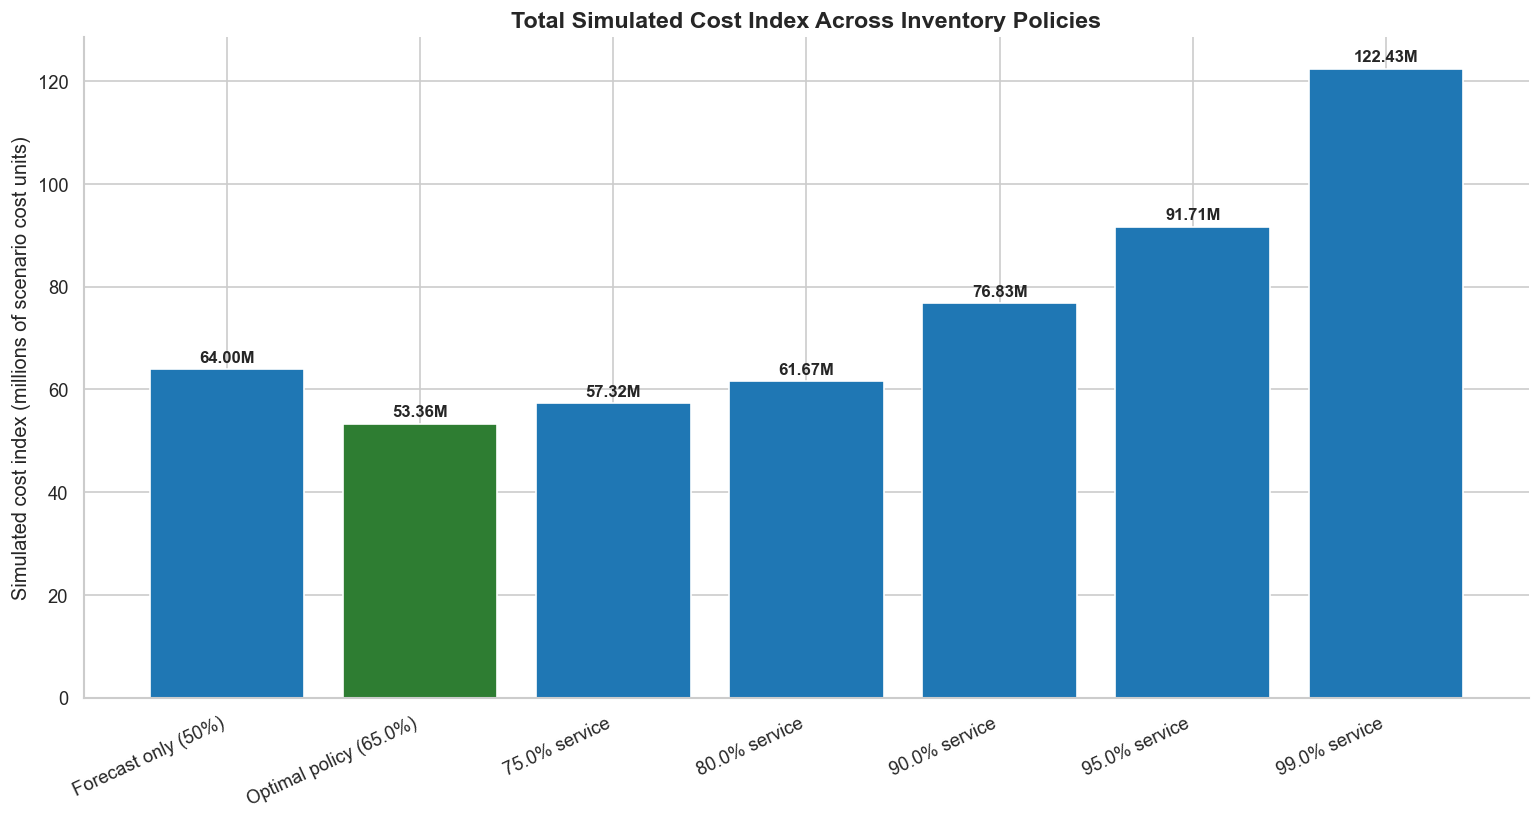

In [32]:
plot_df = policy_comparison.copy()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    plot_df["Policy"],
    plot_df["Total Simulated Cost Index"] / 1e6,
    color=["#2e7d32" if sl == OPTIMAL_SERVICE_LEVEL else "#1f77b4" for sl in plot_df["Service_Level"]]
)

ax.set_title("Total Simulated Cost Index Across Inventory Policies")
ax.set_xlabel("")
ax.set_ylabel("Simulated cost index (millions of scenario cost units)")
plt.xticks(rotation=25, ha="right")

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.2f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 14. Final Inventory Summary

In [33]:
best_policy = (
    service_results
    .sort_values("Total Simulated Cost Index")
    .iloc[0]
)

FORECAST_MODEL_NAME = df["Model"].iloc[0] if "Model" in df.columns else "Optimized DL Ensemble"

final_summary = pd.DataFrame({
    "Measure": [
        "Forecast model",
        "Calibration weeks",
        "Inventory evaluation weeks",
        "Lead time assumption",
        "Holding-cost index",
        "Shortage-cost index",
        "Lowest-cost target service level",
        "Realised fill rate",
        "Stockout-free cycle rate",
        "Average ending inventory",
        "Lost-sales exposure",
        "Total simulated cost index"
    ],
    "Value": [
        FORECAST_MODEL_NAME,
        CALIBRATION_WEEKS,
        len(evaluation_dates),
        LEAD_TIME_WEEKS,
        HOLDING_COST_RATE,
        SHORTAGE_COST_RATE,
        f"{best_policy['Service_Level']:.1%}",
        f"{best_policy['Fill Rate']:.2%}",
        f"{best_policy['Stockout-Free Cycle Rate']:.2%}",
        f"{best_policy['Average Ending Inventory']:,.2f}",
        f"{best_policy['Lost Sales']:,.2f}",
        f"{best_policy['Total Simulated Cost Index']:,.2f} cost units"
    ]
})

display(final_summary)

,Measure,Value
0,Forecast model,Optimized DL Ensemble
1,Calibration weeks,4
2,Inventory evaluation weeks,7
3,Lead time assumption,1
4,Holding-cost index,1.0
5,Shortage-cost index,5.0
6,Lowest-cost target service level,65.0%
7,Realised fill rate,98.35%
8,Stockout-free cycle rate,85.25%
9,Average ending inventory,"1,309.82"


## 15. Save All Outputs

In [34]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "inventory"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

inventory_95.to_csv(OUTPUT_DIR / "inventory_95_service_policy.csv", index=False)
optimal_inventory.to_csv(OUTPUT_DIR / "inventory_optimal_policy.csv", index=False)
group_uncertainty.to_csv(OUTPUT_DIR / "forecast_uncertainty_by_series.csv", index=False)
group_inventory.to_csv(OUTPUT_DIR / "inventory_performance_by_series.csv", index=False)
service_results.to_csv(OUTPUT_DIR / "service_level_sensitivity.csv", index=False)
cost_sensitivity.to_csv(OUTPUT_DIR / "cost_sensitivity.csv", index=False)
policy_comparison.to_csv(OUTPUT_DIR / "inventory_policy_comparison.csv", index=False)
final_summary.to_csv(OUTPUT_DIR / "inventory_final_summary.csv", index=False)

print("Saved inventory analysis to:")
print(OUTPUT_DIR.resolve())

Saved inventory analysis to:
D:\University Of Galway\CT5108 Data Analytics Project\sales-forecasting-inventory-optimization\results\inventory


# Inventory Optimisation Conclusions

The inventory simulation demonstrates how demand forecasts can be transformed into operational replenishment decisions using a periodic-review order-up-to policy.

Forecast uncertainty was estimated separately for each Store–Department series using a four-week calibration period. Local error variance estimates were shrunk toward the global forecast-error variance to improve stability.

Safety stock was calculated as a function of forecast uncertainty, replenishment lead time ($L = 1$), and target service level. This produced heterogeneous safety-stock requirements across Store–Department combinations, reflecting substantial differences in demand predictability.

Increasing target service levels improved realised inventory fill rates and reduced lost-sales exposure, but required greater average inventory, illustrating a clear trade-off between holding-cost exposure and shortage-cost exposure.

Evaluating target service levels across a granular search grid (50.0% to 99.0%) revealed that under primary cost parameters (holding cost index = 1.0, shortage cost index = 5.0), the lowest-cost simulated policy occurred at a target service level of **65.0%**, producing a realised fill rate of **98.35%**, a stockout-free cycle rate of **85.25%**, an average ending inventory of **1,309.82**, and a total simulated cost index of **53,362,825.84 scenario cost units**.

Compared to the unbuffered "Forecast-Only" baseline (50.0% service target, total cost index = 63,995,170.00 cost units), the cost-minimising policy reduced the simulated cost index by approximately **10.63 Million scenario cost units** (**-16.61% cost reduction**).

The sensitivity analysis demonstrated that the optimal target service level shifts dynamically with the shortage-to-holding cost ratio. Higher shortage penalties favored policies with greater safety-stock protection (up to **85.0%** target service level under a 20:1 ratio), whereas lower shortage penalties favored leaner policies (**50.0%** target service level under a 2:1 ratio).

> **Methodological Scope & Limitations:**
> 1. **Evaluation Horizon:** The post-calibration evaluation window (`2012-09-14` to `2012-10-26`) contained no holiday weeks. Holiday forecasting performance was evaluated separately in the forecasting section of the research project.
> 2. **Uncertainty Assumption:** The safety-stock calculation uses a normal approximation to forecast uncertainty. Retail demand errors exhibit tail skewness, so resulting service-level targets should be interpreted as scenario approximations rather than exact probabilistic guarantees.